<a href="https://colab.research.google.com/github/Miguelangel2425/Estancia-de-investigaci-n/blob/main/Ecuaci%C3%B3n_de_Burgers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aquí se presenta una implementación de una Red Neuronal Informada por la Física (PINN) para resolver la ecuación de Burgers viscosa:

$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2}$$

En este primer trozo de código definimos la arquitectura que garantiza la periodicidad mediante transformaciones trigonométricas y la condición inicial que se impone exactamente.

In [5]:
import numpy as np
import torch
import torch.nn as nn
from scipy.stats import qmc
import matplotlib.pyplot as plt

# Condición inicial impuesta exactamente (u0)
def u0(x, L=10):
    arg = (np.sqrt(5)/2) * (x - L/2)
    return (2.5) * (1.0 / torch.cosh(arg))**2

# Transformación de entrada para periodicidad exacta
def transform_input(x, L=10):
    x_space = x[:, 0:1]
    t = x[:, 1:2]
    return torch.cat([
        t,
        torch.cos(2*np.pi*x_space/L),
        torch.sin(2*np.pi*x_space/L)
    ], dim=1)

class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.activation = nn.Tanh()
        self.layers = nn.ModuleList()
        for i in range(len(layers) - 1):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))

    def forward(self, x_input):
        x_space = x_input[:, 0:1]
        t = x_input[:, 1:2]
        x_trans = transform_input(x_input)

        z = x_trans
        for i in range(len(self.layers) - 1):
            z = self.activation(self.layers[i](z))
        N = self.layers[-1](z)

        # Ansatz: u(x,t) = u0(x) + t * N(x,t) -> Garantiza u(x,0) = u0(x)
        return u0(x_space) + t * N

Ahora definimos la ecuación de Burgers y generamos los datos de entrenamiento mediante LHS (Latin Hypercube Sampling).

In [6]:
def burgers_pde(model, x, t, nu):

    x.requires_grad_(True)
    t.requires_grad_(True)

    u = model(torch.cat([x, t], dim=1))

    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u),
                             retain_graph=True, create_graph=True)[0]

    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u),
                             retain_graph=True, create_graph=True)[0]

    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x),
                              retain_graph=True, create_graph=True)[0]

    return u_t + u * u_x - nu * u_xx

# Generación de datos mediante LHS para una exploración óptima del dominio
def generate_training_data(N_f=20000):
    x_min, x_max, t_min, t_max = 0.0, 10.0, 0.0, 2.0
    sampler = qmc.LatinHypercube(d=2)
    sample = sampler.random(N_f)
    X_f = np.zeros_like(sample)
    X_f[:, 0] = x_min + (x_max - x_min) * sample[:, 0]
    X_f[:, 1] = t_min + (t_max - t_min) * sample[:, 1]
    return torch.tensor(X_f, dtype=torch.float32)

Inicializamos la estructura de neuronas que va a tener nuestra PINN y establecemos ADAM como el optimizador.

In [7]:
layers = [3, 50, 50, 50, 50, 1]  # input=3 por cos/sin
model = PINN(layers)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

nu = 0.01 / np.pi

X_f = generate_training_data()

Realizamos el proceso de entrenamiento y observamos la evolución de la función de pérdida con el paso del entrenamiento y cúal es la solución a la que llegamos.

Epoch 0, Loss: 1.876030
Epoch 50, Loss: 0.699019
Epoch 100, Loss: 0.536873
Epoch 150, Loss: 0.241362
Epoch 200, Loss: 0.124582
Epoch 250, Loss: 0.104776
Epoch 300, Loss: 0.093494
Epoch 350, Loss: 0.084350
Epoch 400, Loss: 0.077056
Epoch 450, Loss: 0.072103
Epoch 500, Loss: 0.068284
Epoch 550, Loss: 0.064862
Epoch 600, Loss: 0.061849
Epoch 650, Loss: 0.059368
Epoch 700, Loss: 0.057396
Epoch 750, Loss: 0.057420
Epoch 800, Loss: 0.054453
Epoch 850, Loss: 0.053294
Epoch 900, Loss: 0.052321
Epoch 950, Loss: 0.051527


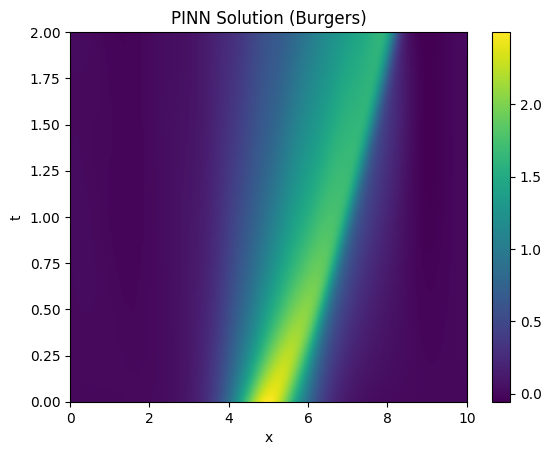

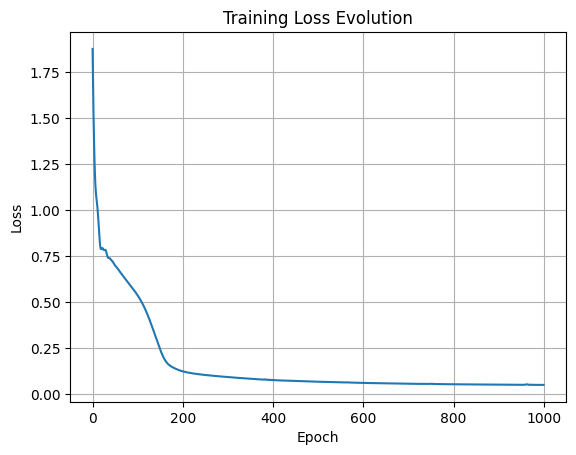

In [8]:
loss_history = []
for epoch in range(1000):

    optimizer.zero_grad()

    x_f = X_f[:, 0:1]
    t_f = X_f[:, 1:2]

    f_pred = burgers_pde(model, x_f, t_f, nu)

    loss = torch.mean(f_pred**2)

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")


# ----------------------------------
# 8. Evaluación
# ----------------------------------

def predict(model, N=200):

    x = np.linspace(0, 10, N)
    t = np.linspace(0, 2, N)

    X, T = np.meshgrid(x, t)
    X_star = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))

    X_star_tensor = torch.tensor(X_star, dtype=torch.float32)

    with torch.no_grad():
        u_pred = model(X_star_tensor).numpy()

    return X, T, u_pred.reshape(X.shape)


# ----------------------------------
# 9. Visualización
# ----------------------------------

import matplotlib.pyplot as plt

X, T, U_pred = predict(model)

plt.imshow(U_pred, extent=[0, 10, 0, 2],
           origin='lower', aspect='auto')
plt.colorbar()
plt.title("PINN Solution (Burgers)")
plt.xlabel("x")
plt.ylabel("t")
plt.show()

plt.figure()
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Evolution")
plt.grid()
plt.show()